# Resultados — `MIL-CREDA` (v1)

Informe ejecutado, no la fuente de la verdad: cada afirmación matemática vive como una prueba bajo `tests/`, y este cuaderno corre las mediciones que esas pruebas ya validan y muestra la evidencia. Reemplaza a los cuadernos de informe y de análisis latente que existían por separado -- `Benchmark_Report_v1.ipynb` y `Benchmark_Latent_v1.ipynb` -- en uno solo, porque las seis secciones de abajo leen el mismo registro y se citan entre sí.

**Todavía no corrió ninguna campaña.** Cada sección lo dice donde le falten sus propios datos, en vez de fallar: lo que sigue es la forma del informe, no un resultado.

Seis secciones, en este orden: el barrido de ruido sobre el piso solo; exactitud de fuente por brazo; exactitud de destino por brazo; los mecanismos de atención sobre el método completo; la representación (geometría, separabilidad, rejillas latentes, correspondencia entre bolsas); y las curvas de pérdida, sólo para comprobar la normalización.

In [1]:
#!/usr/bin/env python3
"""The first code cell of every notebook a job may run — copied byte for byte.

One question, answered once: WHERE IS THE REPOSITORY THIS NOTEBOOK RUNS
AGAINST. Every later cell reads `ROOT` and none of them asks again.

Opened by a person on their own machine, this answers it exactly the way
these notebooks always have. A notebook lives at `<repo>/<Name>/Notebooks/`,
so the repository is two directories above the working directory. Nothing was
handed over, nothing is checked, and the behaviour is unchanged.

Started by a runner on a remote worker, it does not answer it by looking
around. The runner exports the directory it cloned the pinned commit into and
the commit it pinned; this cell reads both, and PROVES the checkout is at that
commit before returning it.

Guessing is the whole reason this cell exists. Under the runner the kernel's
working directory is the runner's own and the clone sits one level inside it,
so two directories up is two levels ABOVE the working directory — a directory
that EXISTS on any worker. The path resolves, the insert succeeds, and the run
dies later with a missing module naming a package, never with the wrong root.
The one fact worth having is the one the failure never mentions.

Three refusals, and each one is a refusal rather than a fallback because this
is the path that spends metered quota:

- **Half a handoff** — one variable present and the other missing. Something
  built this environment and got it half right; that is precisely the state a
  fallback cannot tell apart from a laptop, and the fallback resolves a
  directory that exists everywhere.
- **A root that is not a checkout** — the declared directory is missing, or
  holds no readable `HEAD`. There is nothing to compare against, and an
  unproven root is what this cell was written to stop being acceptable.
- **A checkout at a different commit** — the declared commit and the one on
  disk disagree. A job that runs the wrong commit RUNS: it returns numbers
  shaped exactly like the right ones, and nothing downstream can tell.

Absent means LOCAL. It never means "work it out".

Importable and independently testable, the way the runner's own two cells
are: every function is pure and takes its environment and its working
directory as arguments, and only the last line — the binding a notebook cell
exists to perform — reads the real ones.
"""
import os
from pathlib import Path

#: The directory a runner cloned the pinned commit into. Forge-owned and
#: deliberately generic: this is the contract between a runner and the
#: notebook it starts, not a name borrowed from any one repository.
CLONE_ROOT_ENV = "FORGE_CLONE_ROOT"

#: The commit that clone was pinned to, exported beside it so this cell can
#: check rather than trust. A root on its own would only move the guess one
#: step: a directory handed over is still a directory nobody proved.
CLONE_COMMIT_ENV = "FORGE_CLONE_COMMIT"

#: How far above a notebook's own directory the repository sits when nobody
#: hands anything over: `<repo>/<Name>/Notebooks` -> `<repo>`.
LOCAL_ROOT_DEPTH = 1


def head_commit(root):
    """The commit `root`'s `HEAD` names, read straight out of `.git`.

    No subprocess, deliberately. A notebook cell that shells out needs a git
    binary on a worker's PATH that nothing here declared, and every checker
    that reads these notebooks then has to decide whether running the cell is
    safe — a cell that binds the repository is the last one that may be
    skipped for that reason.

    A pinned checkout is detached: the runner fetches a commit and checks out
    what it fetched, never a branch, so `HEAD` holds the raw commit and this
    is a one-line read. A symbolic `HEAD` is resolved anyway — through the
    loose ref and then `packed-refs` — so pointing these variables at an
    ordinary checkout gets an answer instead of a refusal that would be about
    the file format rather than about the commit.

    Returns `None` when there is nothing to read. The caller turns that into
    a refusal; this function never decides.
    """
    git = Path(root) / ".git"
    if git.is_file():
        pointer = git.read_text(encoding="utf-8").strip()
        if not pointer.startswith("gitdir:"):
            return None
        git = Path(root) / pointer[len("gitdir:"):].strip()
    if not git.is_dir():
        return None
    head = git / "HEAD"
    if not head.is_file():
        return None
    text = head.read_text(encoding="utf-8").strip()
    if not text.startswith("ref:"):
        return text or None
    ref = text[len("ref:"):].strip()
    loose = git / ref
    if loose.is_file():
        return loose.read_text(encoding="utf-8").strip() or None
    packed = git / "packed-refs"
    if packed.is_file():
        for line in packed.read_text(encoding="utf-8").splitlines():
            if line.startswith("#") or line.startswith("^"):
                continue
            fields = line.split()
            if len(fields) == 2 and fields[1] == ref:
                return fields[0]
    return None


def resolve_repository_root(environ=None, cwd=None, head_reader=head_commit):
    """The repository this notebook runs against, or a refusal saying why.

    `environ` and `cwd` are arguments so the whole decision can be driven
    without a kernel, a clone or a worker; the binding at the bottom of this
    cell passes the real ones.
    """
    environ = os.environ if environ is None else environ
    here = Path.cwd() if cwd is None else Path(cwd)
    declared_root = environ.get(CLONE_ROOT_ENV)
    declared_commit = environ.get(CLONE_COMMIT_ENV)

    if not declared_root and not declared_commit:
        return here.parents[LOCAL_ROOT_DEPTH]

    if not declared_root or not declared_commit:
        raise RuntimeError(
            "half a handoff: {0}={1!r} and {2}={3!r}. Both name the pinned "
            "checkout this notebook must run against, and one without the "
            "other is an environment somebody built and got half right. "
            "Falling back to the local layout here would resolve a directory "
            "that exists on any machine and is not this repository.".format(
                CLONE_ROOT_ENV, declared_root,
                CLONE_COMMIT_ENV, declared_commit))

    root = Path(declared_root)
    found = head_reader(root) if root.is_dir() else None
    if found is None:
        raise RuntimeError(
            "{0}={1!r} is not a readable checkout: no commit could be read "
            "from its HEAD. {2} declares {3!r}, and there is nothing here to "
            "check it against.".format(
                CLONE_ROOT_ENV, declared_root,
                CLONE_COMMIT_ENV, declared_commit))
    if found.lower() != declared_commit.lower():
        raise RuntimeError(
            "the checkout at {0}={1!r} is at commit {2}, and {3} declares "
            "{4}. A job that runs a commit nobody asked for RUNS, and the "
            "numbers it returns look exactly like the right ones.".format(
                CLONE_ROOT_ENV, declared_root, found,
                CLONE_COMMIT_ENV, declared_commit))
    return root


ROOT = resolve_repository_root()


In [2]:
# El repositorio ya lo resolvió la celda de arriba -- la de la forja, byte por byte -- y esta sólo lo usa.
import json
import sys
from pathlib import Path

import torch
from IPython.display import Markdown, display

REPOSITORY = ROOT
sys.path.insert(0, str(REPOSITORY / "src"))

from MIL_CREDA_Benchmark import config, figures, harness, latent, tables


def show(text: str) -> None:
    """Una tabla se muestra como tabla, no como texto de ancho fijo."""
    display(Markdown(text))


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FIGURES = config.PRODUCT / "Results" / "figures"
print("repository:", REPOSITORY)
print("device:", DEVICE)

/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repository: /Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation
device: cpu


In [3]:
def cargar_corridas(rate: float = 0.0, kind: str = "campaign"):
    """Las corridas y la reducción de un árbol de resultados, o `(None, None,
    ruta, ensayo)` si esa corrida todavía no dejó registro en ninguna escala.

    La corrida completa le gana siempre al ensayo, y sólo si la completa no
    existe se mira el ensayo -- la misma regla que
    `harness.search_source_note` ya aplica a la búsqueda de techos, acá
    para la campaña. `ensayo` viaja junto al resultado, nunca implícito, para
    que cada celda que dibuja pesos (`latent.latent_grid`, `checkpoint_for`,
    `available`) pueda pasarle la MISMA escala con la que se leyó esto: un
    ensayo que mira el árbol completo, o al revés, dibuja paneles apagados
    sin un solo error que lo delate.

    Glue de este cuaderno y no del banco: pertenece acá porque decide si una
    sección puede correr, y ninguna otra cosa del repositorio necesita
    preguntarlo.
    """
    for ensayo in (False, True):
        raiz = config.results_for(rate, kind, ensayo)
        runs_path = raiz / "runs.jsonl"
        resumen_path = raiz / "summary.json"
        if runs_path.exists() and resumen_path.exists():
            corridas = [json.loads(linea) for linea in
                       runs_path.read_text(encoding="utf-8").splitlines() if linea.strip()]
            resumen = json.loads(resumen_path.read_text(encoding="utf-8"))
            return corridas, resumen.get("reduction", {}), runs_path, ensayo
    return None, None, runs_path, False

## El sello

Los límites de la corrida, dichos una vez y calculados, antes de cualquier número de abajo. La corrida completa le gana siempre al ensayo; si lo que sigue lee del ensayo, lo dice el propio sello de `tables.stamp`.

In [4]:
corridas, reduccion, runs_path, ES_ENSAYO = cargar_corridas()
# De qué árbol salieron los números de abajo -- completo o ensayo --
# dicho siempre y no sólo cuando algo anda mal, el mismo mecanismo que
# `harness.search_source_note` ya usa para los techos.
show(harness.campaign_source_note(ES_ENSAYO if reduccion is not None else None))
if reduccion is not None:
    show(tables.stamp(reduccion, markdown=True))
else:
    show(
        f"**Sin corrida todavía.** No existe `{runs_path.relative_to(ROOT)}`: "
        f"la campaña no corrió, ni a escala completa ni de ensayo, así que no "
        f"hay límites que declarar. Cada sección de abajo lo dice de nuevo "
        f"donde le falten sus propios datos.")
    # El protocolo declarado, no una medición: lo único que las secciones de
    # abajo pueden citar antes de que exista una corrida real.
    reduccion = {"seeds": config.SEEDS, "epochs": config.EPOCHS,
                "backbone": config.BACKBONE, "revision": config.REVISION}

**Estos números son de un ENSAYO**, no de la corrida completa: no hay campaña a escala completa en disco. No se citan como resultados, ni en el informe, ni en el resumen, ni en conversación.

> resnet18  ·  3 épocas  ·  1 repetición(es)  ·  research-concept-r21.md  
> la exactitud se mueve de a 2.78 puntos sobre 36 bolsas de evaluación: nada por debajo de eso lo resuelve una transferencia sola  
> !! 1 repetición(es): el ± de abajo es cero por construcción, no por acuerdo. Son estimaciones puntuales, no resultados.  
> !! piloto: el protocolo declara 30 repeticiones y 20 épocas. Nada de esto es un resultado.  

## 1 · El barrido de ruido — el piso solo

Abre el informe porque responde la pregunta más simple: si el ruido en las etiquetas de entrenamiento perjudica incluso al método que **no adapta**. `MIL-Baseline` (o el piso que `config.FLOOR_OF` declare, nunca un id fijado acá) entrena sólo con la pérdida supervisada de fuente, así que una caída en esta curva no puede venir de ningún término de adaptación -- es lo que el ruido le hace a la propia representación. Dos figuras, fuente y destino, con la misma curva.

In [5]:
# Los pisos declarados hoy, nunca un id escrito acá.
pisos_declarados = sorted(set(config.FLOOR_OF.values()))

### 1a · Fuente

El piso, medido sobre el dominio en el que entrena. Como no adapta, no hay término que pudiera compensar una caída acá: lo que se ve es exactamente lo que la contaminación de las etiquetas de entrenamiento le hace a la representación, sin nada más mezclado en la lectura. Sirve de referencia para la figura de destino que sigue: si la fuente cae poco y el destino cae mucho, la brecha entre dominios es lo que se está ensanchando y no la calidad general del modelo.

In [6]:
show(tables.objective("noise.floor.source"))

> **Buscamos ver si el ruido perjudica incluso al método que no adapta, en fuente.** El piso entrena sólo con etiquetas de fuente, así que una caída acá no puede venir de ningún término de adaptación -- mide cuánto empeora la propia representación cuando el material de entrenamiento está contaminado. El piso de la lectura sigue siendo el azar de 0.100, y lo esperable es que esta curva caiga menos que la de destino: la fuente nunca se contaminó a sí misma, sólo el rótulo que la acompaña.

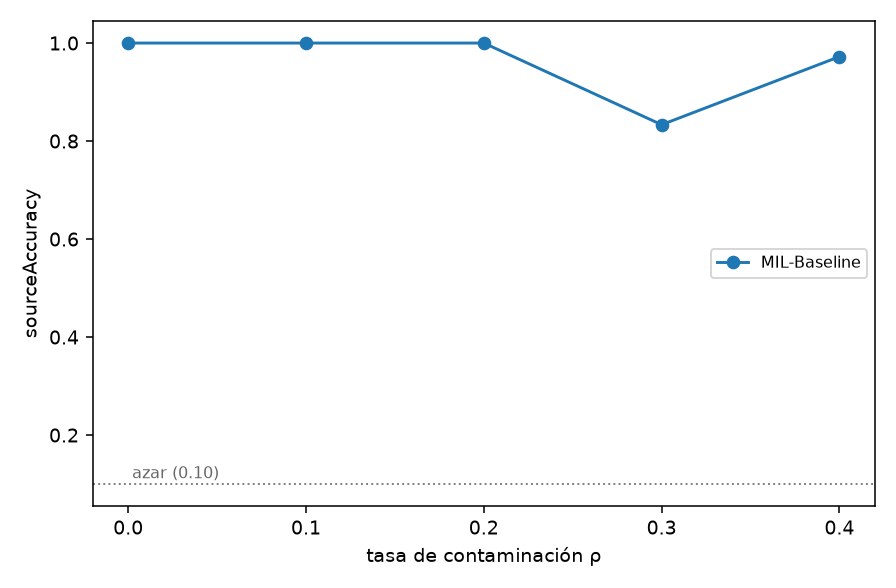

In [7]:
figura_fuente = figures.noise_curves(
    "sourceAccuracy", path=FIGURES / "noise_floor_source.pdf", arms=tuple(pisos_declarados))
display(figures.inline(figura_fuente))

In [8]:
show(tables.conclusion_noise_floor("sourceAccuracy"))

El ruido perjudica incluso al método que no adapta: **MIL-Baseline** cae de 100.0 a 97.2 (+2.8).

### 1b · Destino

El piso, medido sobre el dominio que nunca ve durante el entrenamiento. Es la lectura que más importa de esta sección: un piso entrenado sólo con fuente no tiene ningún mecanismo de adaptación al que la contaminación pudiera llegarle indirectamente, así que cualquier caída acá viene enteramente de que la representación aprendida en fuente generaliza peor a destino cuando el material de entrenamiento está sucio.

In [9]:
show(tables.objective("noise.floor.target"))

> **Buscamos ver si el ruido perjudica incluso al método que no adapta, en destino.** La misma pregunta que la curva de fuente, sobre el dominio que el piso nunca ve durante el entrenamiento: si ni siquiera el destino de un método que no adapta se mueve con el ruido, la contaminación no está llegando a la representación en absoluto. El piso de la lectura sigue siendo el azar de 0.100.

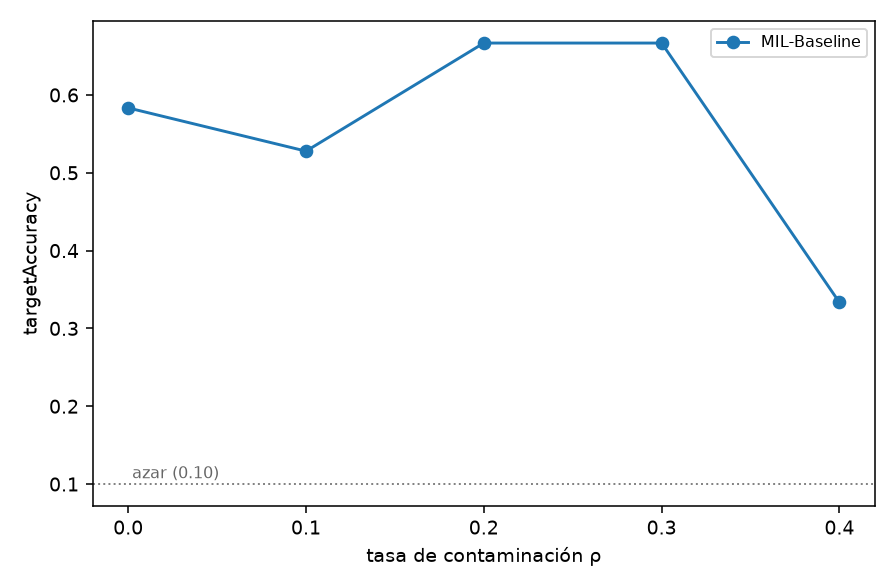

In [10]:
figura_destino = figures.noise_curves(
    "targetAccuracy", path=FIGURES / "noise_floor_target.pdf", arms=tuple(pisos_declarados))
display(figures.inline(figura_destino))

In [11]:
show(tables.conclusion_noise_floor("targetAccuracy"))

El ruido perjudica incluso al método que no adapta: **MIL-Baseline** cae de 58.3 a 33.3 (+25.0).

## 2 · Exactitud de fuente, por brazo

Complemento de la sección siguiente: un método que gana en destino destruyendo la fuente es el caso degenerado, y esta tabla es lo único que lo distingue de un éxito real. Dos bloques -- `sin` ruido y `con` -- con la columna `Ruido` adelante, y un puesto por bloque: dos brazos comparten puesto cuando la diferencia entre sus promedios no supera su error estándar combinado, es decir, cuando esta corrida no alcanza a distinguirlos. Los dos bloques rankean por separado: compartir puesto en `sin` no dice nada sobre `con`.

In [12]:
show(tables.objective("sourceAccuracy"))

> **Buscamos que sea alta y que no caiga** al sumar la adaptación. El piso es el azar de acertar una clase entre 10, o sea 0.100; el techo es 1.000.

In [13]:
if corridas is not None:
    show(tables.render(corridas, "sourceAccuracy", reduccion,
                       rate=config.NOISE_REPORTED, markdown=True))
    show(tables.conclusion_with_noise(corridas, "sourceAccuracy", reduccion,
                                    config.NOISE_REPORTED))
else:
    show(f"**Sin corrida todavía.** No existe `{runs_path.relative_to(ROOT)}`: "
         f"no hay exactitud de fuente que mostrar.")

| Ruido | Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. | Puesto |
|---|---|---|---|---|---|---|---|---|---|
| sin | `MIL-Baseline` | 86.1 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 69.4 ± 0.0 | 100.0 ± 0.0 | 58.3 ± 0.0 | **85.6** | 1 |
| sin | `MIL-CREDA**` | 80.6 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 55.6 ± 0.0 | 100.0 ± 0.0 | 61.1 ± 0.0 | **82.9** | 1 |
| sin | `MIL-CREDA*` | 100.0 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 55.6 ± 0.0 | 100.0 ± 0.0 | 61.1 ± 0.0 | **86.1** | 1 |
| sin | `MIL-CREDA` | 86.1 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 55.6 ± 0.0 | 100.0 ± 0.0 | 61.1 ± 0.0 | **83.8** | 1 |
| con | `MIL-Baseline` | 100.0 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 38.9 ± 0.0 | 100.0 ± 0.0 | 61.1 ± 0.0 | **83.3** | 1 |
| con | `MIL-CREDA**` | 77.8 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 30.6 ± 0.0 | 94.4 ± 0.0 | 52.8 ± 0.0 | **75.9** | 1 |
| con | `MIL-CREDA*` | 63.9 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 30.6 ± 0.0 | 94.4 ± 0.0 | 52.8 ± 0.0 | **73.6** | 1 |
| con | `MIL-CREDA` | 86.1 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 27.8 ± 0.0 | 94.4 ± 0.0 | 50.0 ± 0.0 | **76.4** | 1 |

Mejor promedio: **MIL-CREDA***; peor: MIL-CREDA**, a 3.2% de distancia. MIL-CREDA** queda 2.8% por debajo de su piso MIL-Baseline. MIL-CREDA* queda 0.5% por encima de su piso MIL-Baseline. MIL-CREDA queda 1.9% por debajo de su piso MIL-Baseline. Con 1 repetición(es) esto es una estimación puntual y no un veredicto: la dispersión es cero por construcción, no por acuerdo. Más repeticiones lo refuerzan o lo cambian. Contra el bloque `sin` de arriba, a ρ=0.2 el que menos pierde es `MIL-Baseline` (+2.3) y el que más `MIL-CREDA*` (+12.5). La tabla de arriba pone los dos materiales en dos bloques; la resta entre ellos es lo único que no dice.

## 3 · Exactitud de destino, por brazo

La cabecera del informe: misma forma que la sección anterior, dos bloques y un puesto por bloque, leída **junto a** la tabla de fuente y nunca sola -- una subida acá pagada con una caída allá no es adaptación.

In [14]:
show(tables.objective("targetAccuracy"))

> **Buscamos el valor más alto posible**, entre el azar de 0.100 y 1.000 — y leído junto a la tabla de fuente, porque una subida acá pagada con una caída allá no es adaptación.

In [15]:
if corridas is not None:
    show(tables.render(corridas, "targetAccuracy", reduccion,
                       rate=config.NOISE_REPORTED, markdown=True))
    show(tables.conclusion_with_noise(corridas, "targetAccuracy", reduccion,
                                    config.NOISE_REPORTED))
else:
    show(f"**Sin corrida todavía.** No existe `{runs_path.relative_to(ROOT)}`: "
         f"no hay exactitud de destino que mostrar.")

| Ruido | Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. | Puesto |
|---|---|---|---|---|---|---|---|---|---|
| sin | `MIL-Baseline` | 50.0 ± 0.0 | 72.2 ± 0.0 | 8.3 ± 0.0 | 19.4 ± 0.0 | 27.8 ± 0.0 | 41.7 ± 0.0 | **36.6** | 2 |
| sin | `MIL-CREDA**` | 72.2 ± 0.0 | 88.9 ± 0.0 | 22.2 ± 0.0 | 66.7 ± 0.0 | 27.8 ± 0.0 | 77.8 ± 0.0 | **59.3** | 1 |
| sin | `MIL-CREDA*` | 88.9 ± 0.0 | 94.4 ± 0.0 | 22.2 ± 0.0 | 66.7 ± 0.0 | 27.8 ± 0.0 | 80.6 ± 0.0 | **63.4** | 1 |
| sin | `MIL-CREDA` | 75.0 ± 0.0 | 97.2 ± 0.0 | 22.2 ± 0.0 | 66.7 ± 0.0 | 27.8 ± 0.0 | 80.6 ± 0.0 | **61.6** | 1 |
| con | `MIL-Baseline` | 44.4 ± 0.0 | 66.7 ± 0.0 | 8.3 ± 0.0 | 41.7 ± 0.0 | 13.9 ± 0.0 | 30.6 ± 0.0 | **34.3** | 2 |
| con | `MIL-CREDA**` | 88.9 ± 0.0 | 88.9 ± 0.0 | 16.7 ± 0.0 | 69.4 ± 0.0 | 27.8 ± 0.0 | 52.8 ± 0.0 | **57.4** | 1 |
| con | `MIL-CREDA*` | 63.9 ± 0.0 | 88.9 ± 0.0 | 16.7 ± 0.0 | 69.4 ± 0.0 | 27.8 ± 0.0 | 52.8 ± 0.0 | **53.2** | 1 |
| con | `MIL-CREDA` | 83.3 ± 0.0 | 88.9 ± 0.0 | 16.7 ± 0.0 | 69.4 ± 0.0 | 27.8 ± 0.0 | 52.8 ± 0.0 | **56.5** | 1 |

Mejor promedio: **MIL-CREDA***; peor: MIL-Baseline, a 26.9% de distancia. MIL-CREDA** queda 22.7% por encima de su piso MIL-Baseline. MIL-CREDA* queda 26.9% por encima de su piso MIL-Baseline. MIL-CREDA queda 25.0% por encima de su piso MIL-Baseline. Con 1 repetición(es) esto es una estimación puntual y no un veredicto: la dispersión es cero por construcción, no por acuerdo. Más repeticiones lo refuerzan o lo cambian. Contra el bloque `sin` de arriba, a ρ=0.2 el que menos pierde es `MIL-CREDA**` (+1.9) y el que más `MIL-CREDA*` (+10.2). La tabla de arriba pone los dos materiales en dos bloques; la resta entre ellos es lo único que no dice.

In [16]:
# `render_mechanisms`/`conclusion_mechanisms` ya dicen llanamente que el
# barrido no corrió cuando el registro falta o no declara mecanismos, así
# que se llaman siempre y no adentro de un `if`: eso es lo que las hace
# ejercitadas de verdad y no una rama que nadie recorre todavía. Cargado
# antes del encabezado de la sección para que nada se interponga entre el
# encabezado y la primera lectura que enmarca.
# Por la misma puerta de la que salieron las corridas de arriba, y con la
# misma respuesta: el barrido de mecanismos escribe en el árbol de ensayo
# cuando corre en ensayo, así que una ruta fija a la corrida completa
# dibujaría la Sección 4 como ausente al lado de tablas de piloto que sí
# tienen números. Leer de un árbol lo de una sección y de otro lo de otra
# es cómo un cuaderno termina mezclando dos experimentos en una página.
mechanism_record_path = (config.results_for(0.0, "campaign", ES_ENSAYO)
                         / Path(tables.MECHANISM_RECORD).name)
mechanism_record = (json.loads(mechanism_record_path.read_text(encoding="utf-8"))
                    if mechanism_record_path.exists() else None)


## 4 · Mecanismos de atención — sobre el método completo

Compara mecanismos y no brazos: siempre el método completo (`MIL-CREDA`), con la atención de la Sección 3 tal como este repositorio la implementa contra ABMIL tal como fue publicado (`v_R` sin normalizar), ABMIL con compuerta, `max` y `mean`. Ningún nombre de mecanismo vive en `tables.py`: vienen enteros del registro (`tables.MECHANISM_RECORD`), y si ese registro no existe la sección lo dice en vez de inventar una fila. Dos tablas, fuente y destino.

### 4a · Fuente

Cada mecanismo, medido sobre el dominio en el que el brazo completo entrena. El complemento de la lectura de destino que sigue: un mecanismo que gana en destino hundiendo la fuente no está aportando nada que valga la pena, y esta tabla es la única forma de verlo.

In [17]:
show(tables.objective("sourceAccuracy"))

> **Buscamos que sea alta y que no caiga** al sumar la adaptación. El piso es el azar de acertar una clase entre 10, o sea 0.100; el techo es 1.000.

In [18]:
show(tables.render_mechanisms(mechanism_record, "sourceAccuracy", markdown=True))
show(tables.conclusion_mechanisms(mechanism_record, "sourceAccuracy"))

| Ruido | Mecanismo | M->U | U->M | M->S | S->M | U->S | S->U | Prom. | Puesto |
|---|---|---|---|---|---|---|---|---|---|
| sin | `ours` | 86.1 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 55.6 ± 0.0 | 100.0 ± 0.0 | 61.1 ± 0.0 | **83.8** | 1 |
| sin | `abmil-published` | 61.1 ± 0.0 | 80.6 ± 0.0 | 55.6 ± 0.0 | 47.2 ± 0.0 | 100.0 ± 0.0 | 77.8 ± 0.0 | **70.4** | 1 |
| sin | `abmil-gated` | 63.9 ± 0.0 | 97.2 ± 0.0 | 50.0 ± 0.0 | 44.4 ± 0.0 | 100.0 ± 0.0 | 58.3 ± 0.0 | **69.0** | 1 |
| sin | `max` | 13.9 ± 0.0 | 94.4 ± 0.0 | 38.9 ± 0.0 | 8.3 ± 0.0 | 80.6 ± 0.0 | 5.6 ± 0.0 | **40.3** | 2 |
| sin | `mean` | 94.4 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 30.6 ± 0.0 | 100.0 ± 0.0 | 44.4 ± 0.0 | **78.2** | 1 |
| con | `ours` | 86.1 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 27.8 ± 0.0 | 94.4 ± 0.0 | 50.0 ± 0.0 | **76.4** | 1 |
| con | `abmil-published` | 16.7 ± 0.0 | 100.0 ± 0.0 | 44.4 ± 0.0 | 33.3 ± 0.0 | 91.7 ± 0.0 | 58.3 ± 0.0 | **57.4** | 2 |
| con | `abmil-gated` | 19.4 ± 0.0 | 94.4 ± 0.0 | 41.7 ± 0.0 | 38.9 ± 0.0 | 94.4 ± 0.0 | 33.3 ± 0.0 | **53.7** | 2 |
| con | `max` | 11.1 ± 0.0 | 16.7 ± 0.0 | 22.2 ± 0.0 | 5.6 ± 0.0 | 19.4 ± 0.0 | 19.4 ± 0.0 | **15.7** | 3 |
| con | `mean` | 100.0 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 44.4 ± 0.0 | 97.2 ± 0.0 | 47.2 ± 0.0 | **81.5** | 1 |

En material limpio, el mecanismo que queda adelante es **ours**; el que queda atrás, max, a 43.5% de distancia.

### 4b · Destino

Cada mecanismo, medido sobre el dominio que la adaptación existe para mejorar. La lectura que más importa de esta sección: si el mecanismo de atención de este repositorio queda adelante o atrás de ABMIL publicado, de su variante con compuerta, o de un `max`/`mean` sin atención en absoluto.

In [19]:
show(tables.objective("targetAccuracy"))

> **Buscamos el valor más alto posible**, entre el azar de 0.100 y 1.000 — y leído junto a la tabla de fuente, porque una subida acá pagada con una caída allá no es adaptación.

In [20]:
show(tables.render_mechanisms(mechanism_record, "targetAccuracy", markdown=True))
show(tables.conclusion_mechanisms(mechanism_record, "targetAccuracy"))

| Ruido | Mecanismo | M->U | U->M | M->S | S->M | U->S | S->U | Prom. | Puesto |
|---|---|---|---|---|---|---|---|---|---|
| sin | `ours` | 75.0 ± 0.0 | 97.2 ± 0.0 | 22.2 ± 0.0 | 66.7 ± 0.0 | 27.8 ± 0.0 | 80.6 ± 0.0 | **61.6** | 1 |
| sin | `abmil-published` | 30.6 ± 0.0 | 63.9 ± 0.0 | 16.7 ± 0.0 | 61.1 ± 0.0 | 36.1 ± 0.0 | 41.7 ± 0.0 | **41.7** | 1 |
| sin | `abmil-gated` | 47.2 ± 0.0 | 77.8 ± 0.0 | 25.0 ± 0.0 | 30.6 ± 0.0 | 25.0 ± 0.0 | 72.2 ± 0.0 | **46.3** | 1 |
| sin | `max` | 36.1 ± 0.0 | 61.1 ± 0.0 | 22.2 ± 0.0 | 8.3 ± 0.0 | 8.3 ± 0.0 | 8.3 ± 0.0 | **24.1** | 2 |
| sin | `mean` | 66.7 ± 0.0 | 100.0 ± 0.0 | 11.1 ± 0.0 | 75.0 ± 0.0 | 27.8 ± 0.0 | 58.3 ± 0.0 | **56.5** | 1 |
| con | `ours` | 83.3 ± 0.0 | 88.9 ± 0.0 | 16.7 ± 0.0 | 69.4 ± 0.0 | 27.8 ± 0.0 | 52.8 ± 0.0 | **56.5** | 1 |
| con | `abmil-published` | 19.4 ± 0.0 | 41.7 ± 0.0 | 19.4 ± 0.0 | 44.4 ± 0.0 | 36.1 ± 0.0 | 27.8 ± 0.0 | **31.5** | 2 |
| con | `abmil-gated` | 19.4 ± 0.0 | 91.7 ± 0.0 | 13.9 ± 0.0 | 22.2 ± 0.0 | 30.6 ± 0.0 | 38.9 ± 0.0 | **36.1** | 2 |
| con | `max` | 19.4 ± 0.0 | 11.1 ± 0.0 | 22.2 ± 0.0 | 5.6 ± 0.0 | 16.7 ± 0.0 | 2.8 ± 0.0 | **13.0** | 3 |
| con | `mean` | 91.7 ± 0.0 | 86.1 ± 0.0 | 16.7 ± 0.0 | 75.0 ± 0.0 | 27.8 ± 0.0 | 47.2 ± 0.0 | **57.4** | 1 |

En material limpio, el mecanismo que queda adelante es **ours**; el que queda atrás, max, a 37.5% de distancia.

## 5 · Representación

Si el método alinea las clases entre dominios, o sólo mueve la escala del espacio. En orden: dos tablas cuantitativas (agrupamiento y separabilidad de dominio), cada una limpia y contaminada; la rejilla latente, limpia y contaminada; la figura de bolsas con sus aciertos por brazo; y por último la correspondencia bolsa por bolsa -- de destino a fuente, y su inversa.

In [21]:
# Checkpoints declarados, de esta revisión, con hiperparámetros vigentes y
# que son la mediana propia de su celda -- nunca los extras que una
# promoción apareada agregó para el piso de otro brazo. `ES_ENSAYO` viaja de
# la celda del sello: leer los pesos de una escala mientras se leyó la
# corrida de otra dibujaría paneles apagados sin un solo error que lo avise.
def checkpoints_medianos(rate: float = 0.0, pilot: bool = ES_ENSAYO):
    encontrados = latent.available(rate, pilot)
    return [c for c in encontrados if c["median"] and c["declared"]
           and c["currentRevision"] and c["currentHyperparameters"]]


checkpoints_limpios = checkpoints_medianos(0.0)
checkpoints_sucios = checkpoints_medianos(config.NOISE_REPORTED)
if not checkpoints_limpios:
    show(
        f"**Sin checkpoints todavía.** "
        f"`{config.models_for(0.0, 'campaign', ES_ENSAYO).relative_to(ROOT)}` no "
        f"tiene manifiestos: la campaña no dejó pesos. No es una lectura "
        f"vacía: es que la corrida no existe. El resto de esta sección no "
        f"puede correr sin al menos un checkpoint.")
else:
    # Medido acá, antes del encabezado de 5a, para que nada se interponga
    # entre ese encabezado y la primera lectura que enmarca.
    lecturas_limpias = [latent.analyse(c, DEVICE) for c in checkpoints_limpios]
    lecturas_sucias = [latent.analyse(c, DEVICE) for c in checkpoints_sucios]

### 5a-i · Agrupamiento (razón de distancias)

La razón `cruzada / entre clases` de la Sección 5 del paper, leída en el RKHS que el método alinea y nunca en el embedding euclídeo: baja tanto si la misma clase se juntó entre dominios como si el espacio entero se encogió, y separar esas dos lecturas es lo que la conclusión hace.

In [22]:
show(tables.objective("geometry.ratio"))

> **Buscamos que tienda a cero**, y solo vale si el denominador se sostiene: por debajo de 1.000 la misma clase está más junta entre dominios que dos clases distintas dentro de uno, que es lo que se quiere. Pero una razón también cae si todo colapsa.

In [23]:
if checkpoints_limpios:
    show(tables.render_readings(lecturas_limpias, "geometry.ratio",
                                "razón de distancias", contaminated=lecturas_sucias,
                                rate=config.NOISE_REPORTED, markdown=True))
    show(tables.conclusion_readings_with_noise(
        lecturas_limpias, lecturas_sucias, "geometry.ratio", config.NOISE_REPORTED)
        if lecturas_sucias else tables.conclusion_geometry(lecturas_limpias))

**razón de distancias** — el bloque `con` corrió con las etiquetas de entrenamiento contaminadas a ρ=0.2.

| Ruido | Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|---|
| sin | `MIL-Baseline` | 0.560 ± 0.000 | 0.582 ± 0.000 | 1.215 ± 0.000 | 1.141 ± 0.000 | 1.147 ± 0.000 | 0.787 ± 0.000 | **0.905** |
| sin | `MIL-CREDA**` | 0.477 ± 0.000 | 0.371 ± 0.000 | 1.187 ± 0.000 | 1.174 ± 0.000 | 1.278 ± 0.000 | 0.911 ± 0.000 | **0.900** |
| sin | `MIL-CREDA*` | 0.225 ± 0.000 | 0.365 ± 0.000 | 1.188 ± 0.000 | 1.175 ± 0.000 | 1.275 ± 0.000 | 0.909 ± 0.000 | **0.856** |
| sin | `MIL-CREDA` | 0.384 ± 0.000 | 0.333 ± 0.000 | 1.188 ± 0.000 | 1.174 ± 0.000 | 1.256 ± 0.000 | 0.913 ± 0.000 | **0.875** |
| con | `MIL-Baseline` | 0.718 ± 0.000 | 0.785 ± 0.000 | 1.491 ± 0.000 | 1.488 ± 0.000 | 1.289 ± 0.000 | 1.484 ± 0.000 | **1.209** |
| con | `MIL-CREDA**` | 0.176 ± 0.000 | 0.424 ± 0.000 | 1.453 ± 0.000 | 1.529 ± 0.000 | 1.244 ± 0.000 | 1.334 ± 0.000 | **1.027** |
| con | `MIL-CREDA*` | 0.448 ± 0.000 | 0.426 ± 0.000 | 1.456 ± 0.000 | 1.539 ± 0.000 | 1.246 ± 0.000 | 1.357 ± 0.000 | **1.079** |
| con | `MIL-CREDA` | 0.373 ± 0.000 | 0.407 ± 0.000 | 1.457 ± 0.000 | 1.545 ± 0.000 | 1.235 ± 0.000 | 1.342 ± 0.000 | **1.060** |

Cada método contra su propio piso, transferencia por transferencia. «Alinea» = la razón bajó; «colapsa» = la razón no bajó y la distancia entre clases cayó más del 10%.

Método        piso            alinea  plano  empeora  colapsa
MIL-CREDA     MIL-Baseline         3      0        3        0
MIL-CREDA*    MIL-Baseline         3      0        3        0
MIL-CREDA**   MIL-Baseline         3      0        3        0

Lo que carga peso no es el promedio sino que las transferencias coincidan: un método que alinea en una y empeora en otra no está diciendo nada todavía.
Piloto de 1 repetición(es): estimación puntual, todavía no un veredicto. Entre ρ=0 y ρ=0.2, `MIL-Baseline` es el que más se mueve (+0.3038) y `MIL-CREDA**` el que menos (+0.1266). La tabla de arriba pone los dos materiales en dos bloques; la resta entre ellos es lo único que no dice.

### 5a-ii · Separabilidad de dominio

Qué tan bien un clasificador lineal distingue fuente de destino en el espacio alineado: cerca del azar es lo buscado, porque significa que la información de dominio dejó de estar disponible. Complementa la razón de distancias de arriba -- una mide si las clases se alinearon, ésta mide si los dominios se volvieron indistinguibles.

In [24]:
show(tables.objective("domainSeparability"))

> **Buscamos que se acerque a 0.500**, que es el azar de decidir entre dos dominios. No más bajo: por debajo del azar la regla acierta al revés, que es otra forma de decir que la información de dominio sigue ahí. Un 1.000 es un dominio perfectamente reconocible.

In [25]:
if checkpoints_limpios:
    show(tables.render_readings(lecturas_limpias, "domainSeparability",
                                "separabilidad de dominio", contaminated=lecturas_sucias,
                                rate=config.NOISE_REPORTED, markdown=True))
    show(tables.conclusion_readings_with_noise(
        lecturas_limpias, lecturas_sucias, "domainSeparability", config.NOISE_REPORTED)
        if lecturas_sucias else tables.conclusion_separability(lecturas_limpias))

**separabilidad de dominio** — el bloque `con` corrió con las etiquetas de entrenamiento contaminadas a ρ=0.2.

| Ruido | Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|---|
| sin | `MIL-Baseline` | 0.918 ± 0.000 | 0.806 ± 0.000 | 0.861 ± 0.000 | 0.987 ± 0.000 | 0.903 ± 0.000 | 0.920 ± 0.000 | **0.899** |
| sin | `MIL-CREDA**` | 0.795 ± 0.000 | 0.792 ± 0.000 | 0.890 ± 0.000 | 0.986 ± 0.000 | 0.903 ± 0.000 | 0.889 ± 0.000 | **0.876** |
| sin | `MIL-CREDA*` | 0.638 ± 0.000 | 0.766 ± 0.000 | 0.890 ± 0.000 | 0.986 ± 0.000 | 0.903 ± 0.000 | 0.889 ± 0.000 | **0.845** |
| sin | `MIL-CREDA` | 0.818 ± 0.000 | 0.766 ± 0.000 | 0.890 ± 0.000 | 0.986 ± 0.000 | 0.903 ± 0.000 | 0.874 ± 0.000 | **0.873** |
| con | `MIL-Baseline` | 0.904 ± 0.000 | 0.930 ± 0.000 | 0.947 ± 0.000 | 0.986 ± 0.000 | 0.960 ± 0.000 | 1.000 ± 0.000 | **0.954** |
| con | `MIL-CREDA**` | 0.918 ± 0.000 | 0.863 ± 0.000 | 0.918 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | **0.950** |
| con | `MIL-CREDA*` | 0.876 ± 0.000 | 0.863 ± 0.000 | 0.918 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | **0.943** |
| con | `MIL-CREDA` | 0.710 ± 0.000 | 0.863 ± 0.000 | 0.918 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | 1.000 ± 0.000 | **0.915** |

Una diferencia negativa es mejor: la regla de dominio quedó más cerca del azar que en el mismo método sin adaptación. MIL-CREDA contra MIL-Baseline, distancia al azar: las transferencias no coinciden — 1 a favor, 3 en contra, 2 planas (M->S +0.029, M->U -0.100, S->M -0.001, S->U -0.046, U->M -0.040, U->S +0.000). Un promedio acá diría 'no hace nada' y estaría tapando que una transferencia sí se movió. MIL-CREDA* contra MIL-Baseline, distancia al azar: las transferencias no coinciden — 1 a favor, 3 en contra, 2 planas (M->S +0.029, M->U -0.280, S->M -0.001, S->U -0.031, U->M -0.040, U->S +0.000). Un promedio acá diría 'no hace nada' y estaría tapando que una transferencia sí se movió. MIL-CREDA** contra MIL-Baseline, distancia al azar: las transferencias no coinciden — 1 a favor, 3 en contra, 2 planas (M->S +0.029, M->U -0.123, S->M -0.001, S->U -0.031, U->M -0.013, U->S +0.000). Un promedio acá diría 'no hace nada' y estaría tapando que una transferencia sí se movió. Piloto de 1 repetición(es): estimación puntual, todavía no un veredicto. Entre ρ=0 y ρ=0.2, `MIL-CREDA*` es el que más se mueve (+0.09778) y `MIL-CREDA` el que menos (+0.04238). La tabla de arriba pone los dos materiales en dos bloques; la resta entre ellos es lo único que no dice.

In [26]:
if checkpoints_limpios:
    corridas_para_semilla = corridas if corridas is not None else [
        {"seed": c["seed"], "targetAccuracy": c["targetAccuracy"]} for c in checkpoints_limpios]
    semilla_exhibicion = latent.display_seed(corridas_para_semilla)
    transferencias_grilla = tables.best_transfers(corridas) if corridas else [
        f"{s}->{t}" for s, t in config.VERDICT_TRANSFERS[:config.FIGURE_TRANSFER_COUNT]]

### 5b · Rejilla latente, limpia

El espacio compartido de la Sección 5a, mostrado y no sólo medido: una fila por transferencia -- las que la campaña alcanzó más alto, la misma regla que las figuras de curvas -- y una columna por método de `config.LATENT_PANELS`, todos dibujados a nivel de instancia porque es el único espacio que cada arm tiene. La semilla es la de exhibición, elegida por una regla que no favorece a ningún método.

In [27]:
show(tables.objective("latent.grid.clean"))

> **Buscamos ver si las clases se mezclan entre dominios y siguen separadas entre sí, sobre material limpio.** Un panel por método, el espacio original primero: «alineado» no se ve sin un «no alineado» al lado, que es lo que el primer panel de la fila da.

/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


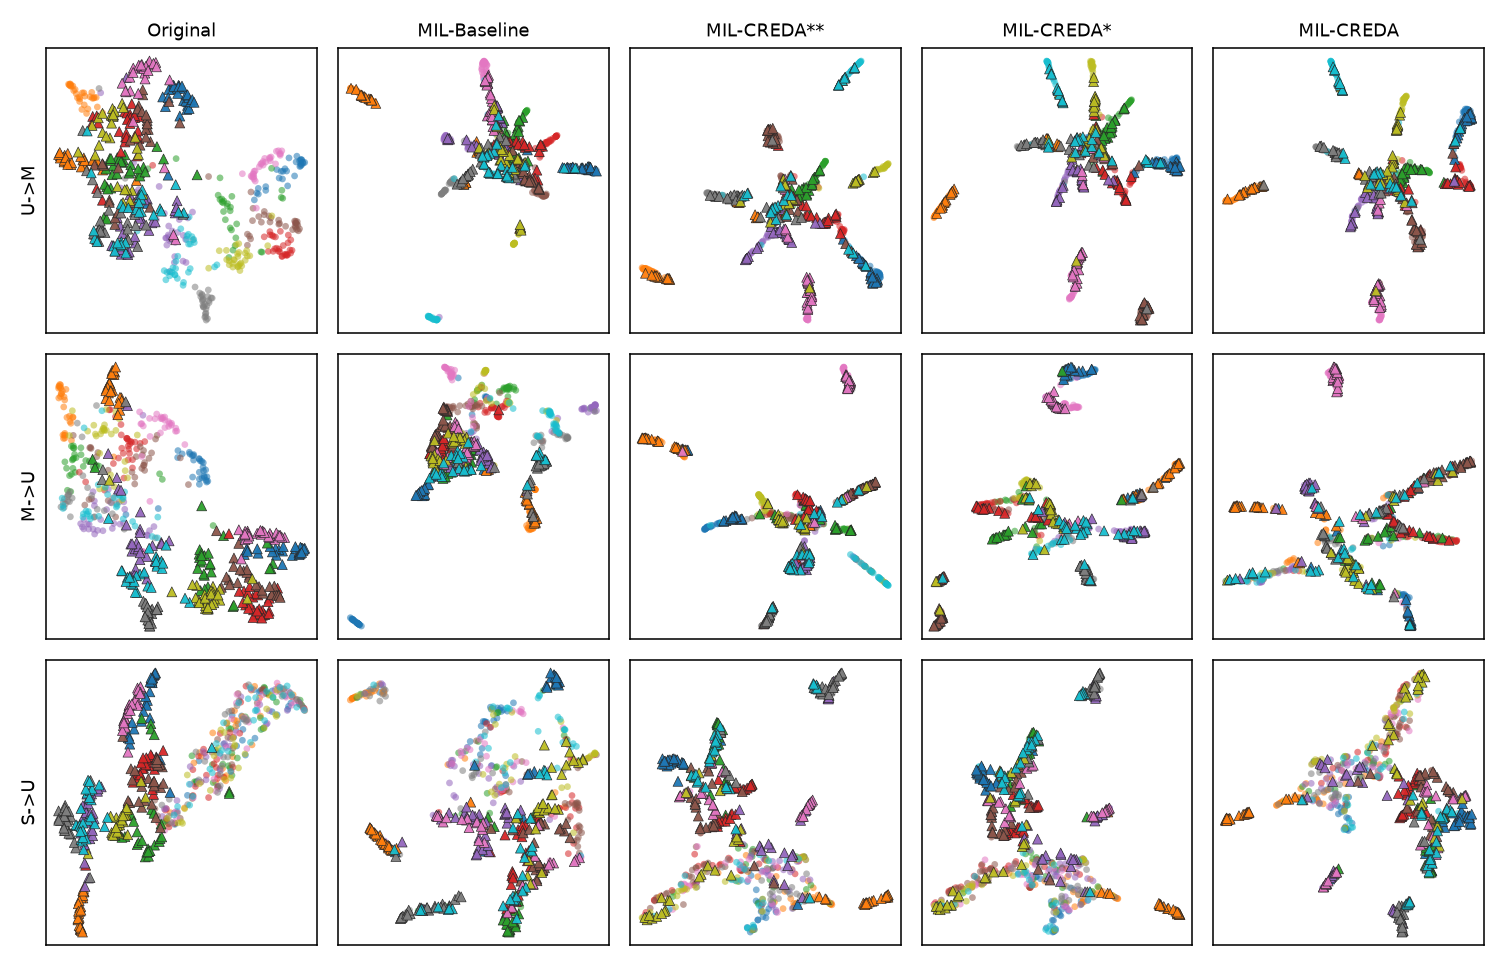

In [28]:
if checkpoints_limpios:
    rejilla = latent.latent_grid(
        FIGURES / "latent_grid_clean.pdf", config.LATENT_PANELS,
        transferencias_grilla, semilla_exhibicion, DEVICE, rate=0.0,
        pilot=ES_ENSAYO)
    display(figures.inline(rejilla))

In [29]:
if checkpoints_limpios:
    show(tables.conclusion_distances(lecturas_limpias))

MIL-CREDA contra MIL-Baseline: misma clase entre dominios +32.6%, clases distintas +51.6% sobre 6 transferencia(s) — la misma clase se juntó más de lo que se encogió el espacio. MIL-CREDA* contra MIL-Baseline: misma clase entre dominios +27.1%, clases distintas +63.4% sobre 6 transferencia(s) — la misma clase se juntó más de lo que se encogió el espacio. MIL-CREDA** contra MIL-Baseline: misma clase entre dominios +53.2%, clases distintas +64.2% sobre 6 transferencia(s) — la misma clase se juntó más de lo que se encogió el espacio. Piloto de 1 repetición(es): estimación puntual, todavía no un veredicto.

### 5c · La figura de bolsas, limpia

Tres columnas -- el piso, el mismo método sin término local y el completo, elegidas por el mecanismo (`config.BAG_PANELS`) y no por la clasificación -- con la misma bolsa mediana de cada clase destacada en cada panel. Los números de la figura, como tabla y no como pie de imagen, donde se comparan de una fila a otra.

In [30]:
show(tables.objective("correspondence.grid.clean"))

> **Buscamos que el triángulo destacado caiga entre círculos de su mismo color, en material limpio**, y que eso pase más en la columna con término local que en la de al lado -- esa comparación es la razón de que el piso, la versión sin término local y la completa compartan la misma fila.

/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


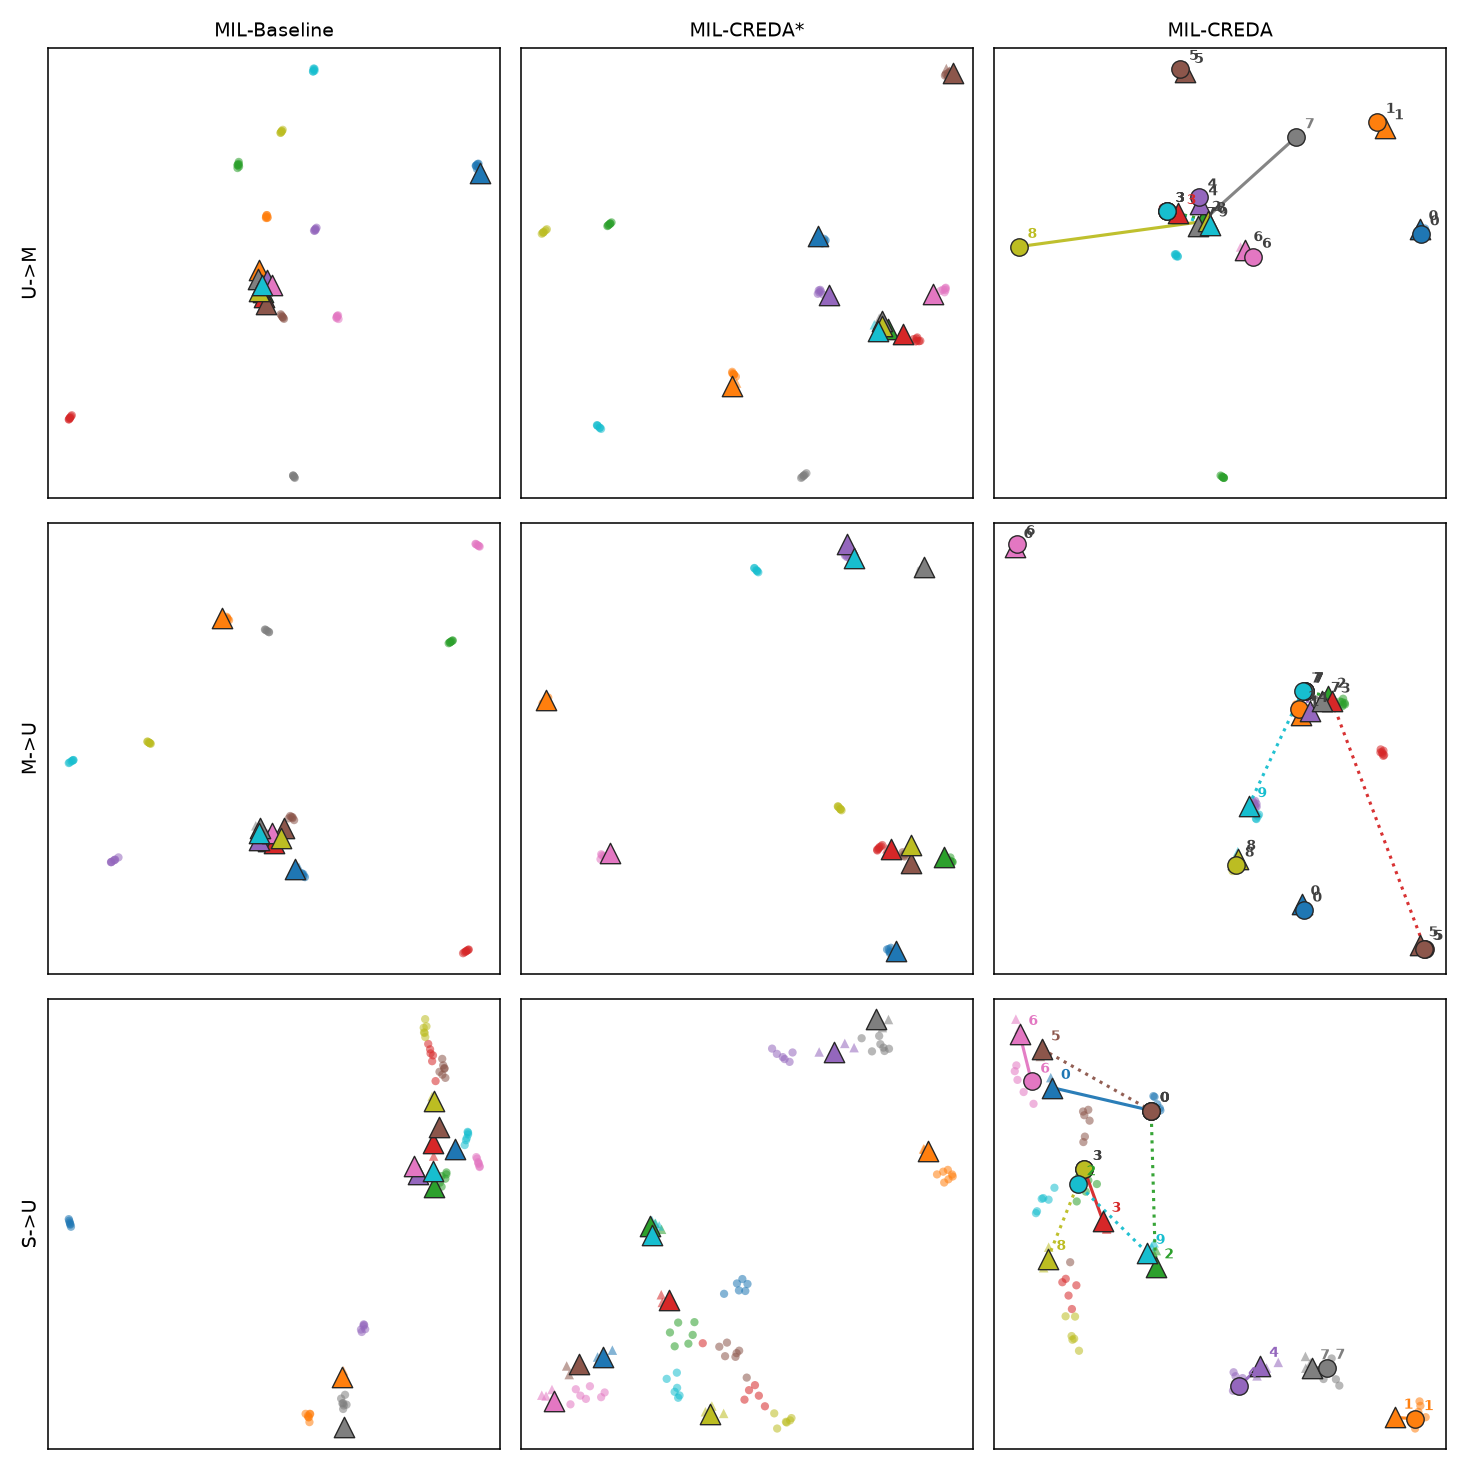

In [31]:
if checkpoints_limpios:
    rejilla_bolsas = latent.correspondence_grid(
        FIGURES / "correspondence_grid_clean.pdf", config.BAG_PANELS,
        transferencias_grilla, semilla_exhibicion, DEVICE, rate=0.0,
        pilot=ES_ENSAYO)
    display(figures.inline(rejilla_bolsas["figure"]))

### 5c-i · Los aciertos, en números

Vivían dentro de la figura de arriba, como pie de cada panel. Ahí obligaban a leer una cifra dentro de un dibujo, que es donde peor se compara, y de paso hacían que las tres columnas se vieran igual de afirmativas. La figura queda para lo que hace bien -- mostrar si los sujetos se asocian -- y los números quedan acá, donde se comparan de una fila a otra.

In [32]:
show(tables.objective("correspondence"))

> **Buscamos que el triángulo destacado caiga entre círculos de su mismo color**, y que eso pase más en la columna con término local que en la de al lado. El azar de acertar la clase es 0.100.

In [33]:
if checkpoints_limpios:
    show(tables.render_correspondence(rejilla_bolsas["scored"], markdown=True))
    show(tables.conclusion_correspondence(rejilla_bolsas["scored"]))

| Método | Qué computa | U->M | M->U | S->U | Masa prom. |
|---|---|---|---|---|---|
| `MIL-Baseline` | sin adaptación: solo fuente | 6/10 | 4/10 | 4/10 | **0.494** |
| `MIL-CREDA*` | adaptación milcreda, ponderada, sin término local | 8/10 | 9/10 | 6/10 | **0.805** |
| `MIL-CREDA` | adaptación milcreda, ponderada, con término local | 8/10 | 6/10 | 6/10 | **0.804** |

Empareja mejor **MIL-CREDA***, sumando sus transferencias; el azar de acertar una clase es 0.100. El término local, aislado como MIL-CREDA contra MIL-CREDA*: las transferencias no coinciden — 1 a favor, 1 en contra, 1 planas (M->U -0.032, S->U +0.001, U->M +0.028). Un promedio acá diría 'no hace nada' y estaría tapando que una transferencia sí se movió. Escala no verificable: esta conclusión no recibió las mediciones con las que contar repeticiones.

### 5c (cont.) · La figura de bolsas, contaminada

La misma figura sobre la campaña contaminada, con la misma tabla de aciertos al lado. Leída junto a la limpia: si la correspondencia local sobrevive al ruido mejor que la global es exactamente lo que esta comparación existe para mostrar, y es una lectura distinta de las dos tablas de la Sección 5a -- ésas miden geometría global, ésta mide si el emparejamiento bolsa a bolsa sigue siendo correcto.

In [34]:
show(tables.objective("correspondence.grid.noisy"))

> **Buscamos si la correspondencia local sobrevive al ruido mejor que la global.** La misma figura, sobre el material contaminado, leída junto a la limpia y nunca por separado.

/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


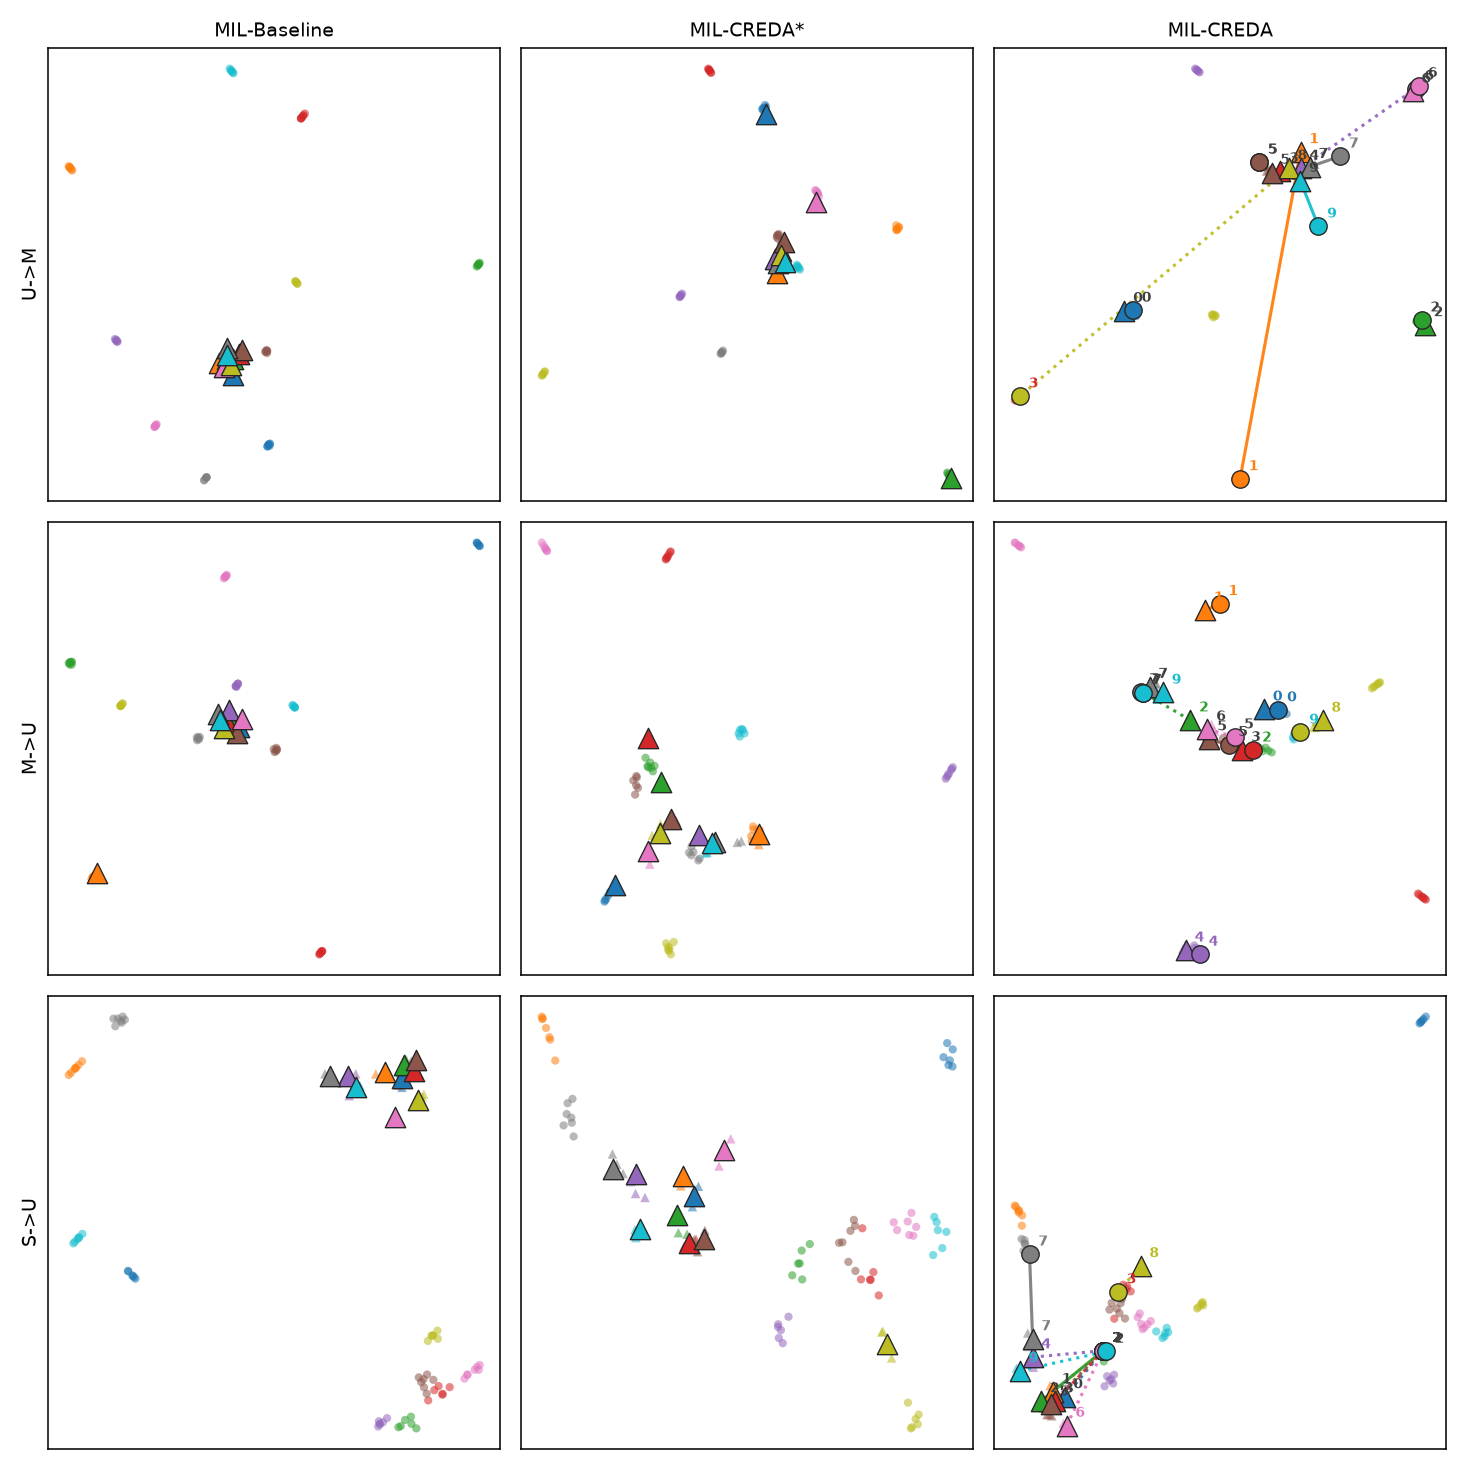

In [35]:
if checkpoints_limpios and checkpoints_sucios:
    rejilla_bolsas_sucia = latent.correspondence_grid(
        FIGURES / "correspondence_grid_noisy.pdf", config.BAG_PANELS,
        transferencias_grilla, semilla_exhibicion, DEVICE,
        rate=config.NOISE_REPORTED, pilot=ES_ENSAYO)
    display(figures.inline(rejilla_bolsas_sucia["figure"]))
elif checkpoints_limpios:
    show(f"**Sin checkpoints contaminados a ρ={config.NOISE_REPORTED:g}.** "
         f"La figura de bolsas limpia queda sola.")

### 5c-ii · Los aciertos, en números, contaminados

La misma tabla de aciertos sobre la campaña contaminada, leída junto a la limpia de arriba y nunca por separado: si el aporte del término local sobrevive al ruido es la comparación fila a fila entre las dos.

In [36]:
show(tables.objective("correspondence"))

> **Buscamos que el triángulo destacado caiga entre círculos de su mismo color**, y que eso pase más en la columna con término local que en la de al lado. El azar de acertar la clase es 0.100.

In [37]:
if checkpoints_limpios and checkpoints_sucios:
    show(tables.render_correspondence_contaminated(
        rejilla_bolsas_sucia["scored"], config.NOISE_REPORTED, markdown=True))
    show(tables.conclusion_correspondence(rejilla_bolsas_sucia["scored"]))

| Método | Qué computa | U->M | M->U | S->U | Masa prom. |
|---|---|---|---|---|---|
| `MIL-Baseline` | sin adaptación: solo fuente | 4/10 | 3/10 | 2/10 | **0.414** |
| `MIL-CREDA*` | adaptación milcreda, ponderada, sin término local | 7/10 | 4/10 | 2/10 | **0.652** |
| `MIL-CREDA` | adaptación milcreda, ponderada, con término local | 7/10 | 5/10 | 2/10 | **0.709** |

Empareja mejor **MIL-CREDA**, sumando sus transferencias; el azar de acertar una clase es 0.100. El término local, aislado como MIL-CREDA contra MIL-CREDA*: las transferencias no coinciden — 1 a favor, 0 en contra, 2 planas (M->U +0.162, S->U +0.009, U->M +0.002). Un promedio acá diría 'no hace nada' y estaría tapando que una transferencia sí se movió. Escala no verificable: esta conclusión no recibió las mediciones con las que contar repeticiones.

### 5d · Bolsas de destino y sus 5 bolsas fuente más cercanas

El brazo completo, sobre la transferencia y semilla de exhibición: por cada bolsa de evaluación de destino, sus cinco bolsas fuente de entrenamiento más cercanas por el kernel de bolsa de la Sección 3 -- sobre TODAS las bolsas fuente, nunca un subconjunto -- en orden de cercanía, cada una con su propia clase entre paréntesis. La clase de la bolsa de destino está en su propia columna al lado, así que la fila deja ver de un vistazo si las vecinas más cercanas son de clases parecidas.

In [38]:
show(tables.objective("correspondence"))

> **Buscamos que el triángulo destacado caiga entre círculos de su mismo color**, y que eso pase más en la columna con término local que en la de al lado. El azar de acertar la clase es 0.100.

In [39]:
if checkpoints_limpios:
    arm_completo = next(
        (a for a in config.BAG_PANELS if config.ARMS_BY_ID[a]["local"]), None)
if checkpoints_limpios and arm_completo is None:
    show("Ningún brazo de `config.BAG_PANELS` declara término local: no hay "
         "método completo sobre el que medir la correspondencia.")
elif checkpoints_limpios:
    checkpoint_completo = latent.checkpoint_for(
        arm_completo, transferencias_grilla[0], semilla_exhibicion, rate=0.0,
        pilot=ES_ENSAYO)
    if checkpoint_completo is None:
        show(f"**Sin checkpoint de `{config.NAME_OF[arm_completo]}`** en "
             f"`{transferencias_grilla[0]}` semilla {semilla_exhibicion}: no hay "
             f"correspondencia que medir para esa celda todavía.")
    else:
        modelo, fuente, destino = latent.load(checkpoint_completo, DEVICE)
        referencia = latent.bag_pairs(modelo, fuente, destino, DEVICE)
        vecinos = latent.top_k_source_bags(referencia, k=5)
        show(tables.render_bag_neighbors(vecinos, markdown=True))
        show(tables.conclusion_bag_neighbors(vecinos))

| Bolsa destino | Clase | Vecinos fuente (clase) |
|---|---|---|
| 0 | 0 | 5 (0), 0 (0), 4 (0), 6 (0), 3 (0) |
| 1 | 0 | 4 (0), 0 (0), 5 (0), 6 (0), 3 (0) |
| 2 | 0 | 5 (0), 0 (0), 4 (0), 6 (0), 3 (0) |
| 3 | 0 | 5 (0), 0 (0), 4 (0), 6 (0), 3 (0) |
| 4 | 1 | 8 (1), 11 (1), 13 (1), 9 (1), 12 (1) |
| 5 | 1 | 8 (1), 11 (1), 13 (1), 9 (1), 12 (1) |
| 6 | 1 | 11 (1), 8 (1), 9 (1), 13 (1), 12 (1) |
| 7 | 1 | 11 (1), 8 (1), 9 (1), 13 (1), 12 (1) |
| 8 | 2 | 24 (3), 21 (3), 22 (3), 27 (3), 18 (2) |
| 9 | 2 | 24 (3), 21 (3), 22 (3), 27 (3), 26 (3) |
| 10 | 2 | 24 (3), 21 (3), 22 (3), 27 (3), 26 (3) |
| 11 | 3 | 24 (3), 22 (3), 27 (3), 21 (3), 26 (3) |
| 12 | 3 | 24 (3), 22 (3), 27 (3), 21 (3), 26 (3) |
| 13 | 3 | 24 (3), 22 (3), 27 (3), 21 (3), 26 (3) |
| 14 | 4 | 31 (4), 29 (4), 30 (4), 33 (4), 28 (4) |
| 15 | 4 | 31 (4), 24 (3), 21 (3), 22 (3), 27 (3) |
| 16 | 4 | 31 (4), 29 (4), 30 (4), 24 (3), 21 (3) |
| 17 | 5 | 39 (5), 37 (5), 34 (5), 35 (5), 38 (5) |
| 18 | 5 | 37 (5), 34 (5), 39 (5), 38 (5), 35 (5) |
| 19 | 5 | 37 (5), 39 (5), 34 (5), 38 (5), 35 (5) |
| 20 | 5 | 37 (5), 39 (5), 35 (5), 34 (5), 38 (5) |
| 21 | 6 | 42 (6), 40 (6), 44 (6), 43 (6), 41 (6) |
| 22 | 6 | 44 (6), 42 (6), 40 (6), 43 (6), 41 (6) |
| 23 | 6 | 42 (6), 40 (6), 41 (6), 44 (6), 45 (6) |
| 24 | 6 | 44 (6), 42 (6), 40 (6), 43 (6), 34 (5) |
| 25 | 7 | 50 (7), 46 (7), 49 (7), 47 (7), 48 (7) |
| 26 | 7 | 50 (7), 49 (7), 46 (7), 47 (7), 48 (7) |
| 27 | 7 | 50 (7), 46 (7), 49 (7), 47 (7), 48 (7) |
| 28 | 7 | 50 (7), 49 (7), 47 (7), 46 (7), 48 (7) |
| 29 | 8 | 56 (8), 54 (8), 55 (8), 52 (8), 57 (8) |
| 30 | 8 | 56 (8), 21 (3), 24 (3), 27 (3), 22 (3) |
| 31 | 8 | 56 (8), 21 (3), 24 (3), 27 (3), 22 (3) |
| 32 | 9 | 61 (9), 58 (9), 59 (9), 63 (9), 24 (3) |
| 33 | 9 | 24 (3), 21 (3), 22 (3), 27 (3), 26 (3) |
| 34 | 9 | 24 (3), 21 (3), 22 (3), 27 (3), 26 (3) |
| 35 | 9 | 24 (3), 21 (3), 22 (3), 27 (3), 26 (3) |

Cada vecino es la bolsa fuente y, entre paréntesis, su propia clase; van en orden de cercanía por el kernel de bolsa de la Sección 3, de la más cercana a la más lejana.

En 135 de 180 vecinos (top-5) el kernel eligió una bolsa fuente de la misma clase. 24 de 36 bolsas de destino tienen el top-5 entero de su propia clase; 5 no tienen ninguno.

## 6 · Curvas de pérdida — sólo para comprobar la normalización

No para leer una trayectoria: para comprobar que el término de la Ec. (39) se queda en la misma escala [0, 1) que la normalización promete. La banda sombreada de cada panel es exactamente ese intervalo, y la conclusión que sigue no dice qué brazo tiene la curva más baja -- dice si algún punto, de algún brazo, de alguna corrida, se salió del intervalo. Una figura, el término de adaptación, sobre las dos condiciones a la vez.

### 6a · Término de adaptación

Cada brazo adaptado (`config.FLOOR_OF`, nunca un id escrito acá), una columna por transferencia y una fila por condición: arriba la corrida limpia, abajo la contaminada a `config.NOISE_REPORTED`. Una columna se lee de arriba a abajo -- es la misma transferencia en las dos filas, y la figura lo comprueba en vez de suponerlo -- así que un término que se sale del intervalo bajo contaminación y no en limpio se ve en la columna y no cruzando dos figuras. Section 5's arm completo aparte no importa acá: lo que se comprueba es si la construcción de la Sección 5 del paper mantiene el término dentro de [0, 1) para TODOS los brazos que lo llevan, no sólo para el que gana.

In [40]:
show(tables.objective("adaptation"))

> **Buscamos que la curva viva dentro de [0, 1] y tienda a cero**, y que ocupe la misma parte del intervalo en las seis transferencias. Salirse de la banda o cambiar de escala entre pares de dominios es el hallazgo.

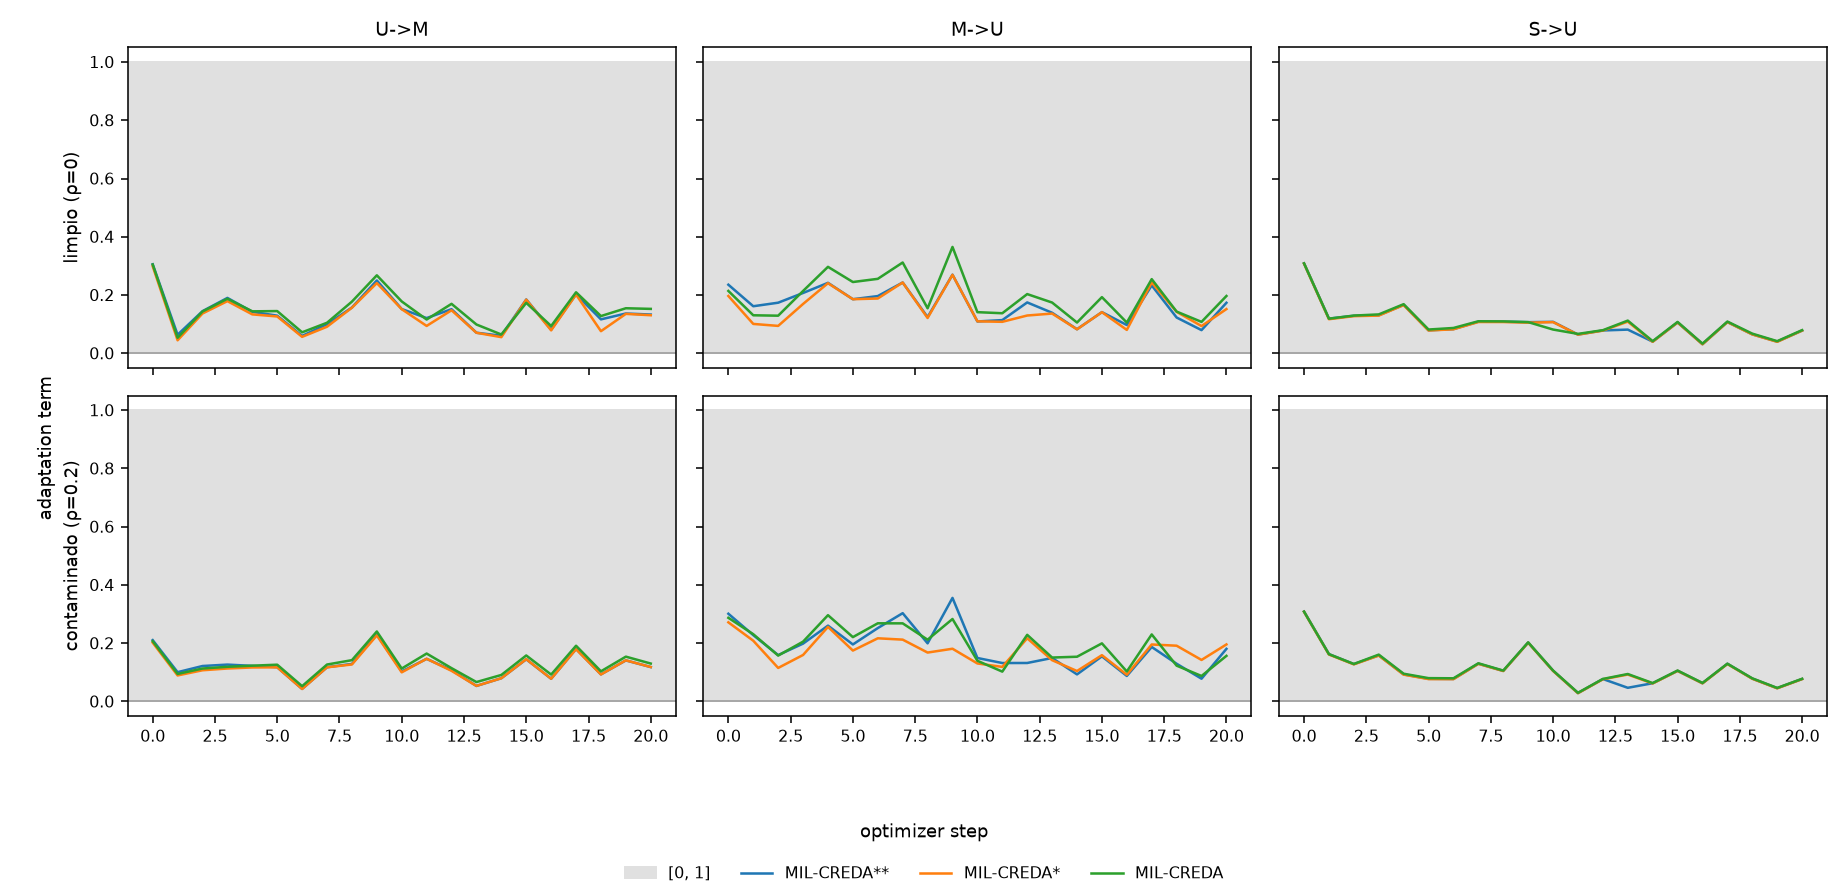

In [41]:
# La fila contaminada sale de SU propio árbol, resuelto por la misma puerta
# que resolvió la limpia (`cargar_corridas`) y nunca por una ruta escrita a
# mano. La escala viaja con cada una: dibujar una corrida completa encima de
# un ensayo pondría dos experimentos en una figura sin que nada lo dijera, así
# que la fila de abajo se dibuja sólo si su escala es la misma, y si no, se
# dice cuál falta.
corridas_sucias, _, runs_path_sucio, ES_ENSAYO_SUCIO = cargar_corridas(config.NOISE_REPORTED)
filas_adaptacion = [("limpio (ρ=0)", runs_path)]
if corridas is not None and corridas_sucias is not None and ES_ENSAYO_SUCIO == ES_ENSAYO:
    filas_adaptacion.append(
        (f"contaminado (ρ={config.NOISE_REPORTED:g})", runs_path_sucio))

if corridas is not None:
    figura_adaptacion = figures.adaptation_curves(
        FIGURES / "adaptation_curves.pdf",
        arms=tuple(sorted(config.FLOOR_OF)), runs=filas_adaptacion,
        transfers=tables.best_transfers(corridas))
    display(figures.inline(figura_adaptacion))
    if len(filas_adaptacion) == 1:
        show(f"**Sin la fila contaminada.** No hay corrida a "
             f"ρ={config.NOISE_REPORTED:g} a la misma escala que la limpia: la "
             f"figura queda con la condición limpia sola.")
else:
    show(f"**Sin corrida todavía.** No existe `{runs_path.relative_to(ROOT)}`: "
         f"no hay curva de adaptación que dibujar.")

In [42]:
if corridas is not None:
    show(tables.conclusion_normalization(corridas, "adaptation"))

La curva se queda dentro de [0, 1) en toda esta corrida: mínimo 0.0000, máximo 0.3651. La normalización se sostiene.

## El sello del código

In [43]:
# Contra qué código corrió este informe. Sin él, un informe viejo y uno
# recién generado se ven idénticos y el viejo se sigue creyendo.
from MIL_CREDA_Benchmark import report_digest

print(report_digest.stamp())

SOURCES-SHA256 df7c09806998df4a361af374ff39a396afe3a6434c6d81704b18956aec40aba5
